#Deep Learning para visión de computadoras
##Lab 1.3 Arquitecturas CNN de referencia: LeNet-5, AlexNet, GoogLeNet y VGG16

**Unidad 1.** Fundamentos de visión por computadora y redes convolucionales
**1.3** Arquitecturas CNN para clasificación

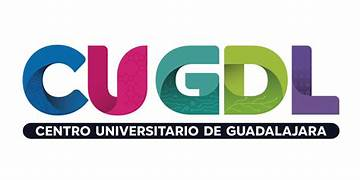

Esta práctica toma como referencia *"Arquitecturas de Redes Convolucionales"* (LeNet-5, AlexNet, GoogLeNet, VGG16), parte A definicion original de los modelos y parte B entrenamiento y evalúación sobre CIFAR-10, para poder comparar capacidad, número de parámetros, tiempo de entrenamiento y desempeño real.

**Objetivos de la práctica**
1. Implementar en PyTorch cuatro arquitecturas CNN clásicas adaptadas a CIFAR-10.
2. Entrenar y evaluar cada una bajo las mismas condiciones (mismos datos, épocas, optimizador).
3. Comparar número de parámetros, tiempo de entrenamiento y accuracy de test.
4. Discutir la relación entre profundidad/capacidad del modelo y su desempeño/eficiencia.

#PARTE A
### Arquitecturas de Redes Convolucionales
En el campo del deep learning y computer vision, una de estas competiciones, que hoy en día ya es un benchmark establecido, es la clasificación de imágenes en el dataset Imagenet. En 2012, la primera red neuronal convolucional entró en esta competición consiguiendo una mejora de 10 puntos sobre la mejor solución hasta la fecha, lo cual supuso un detonante para el campo del deep learning.

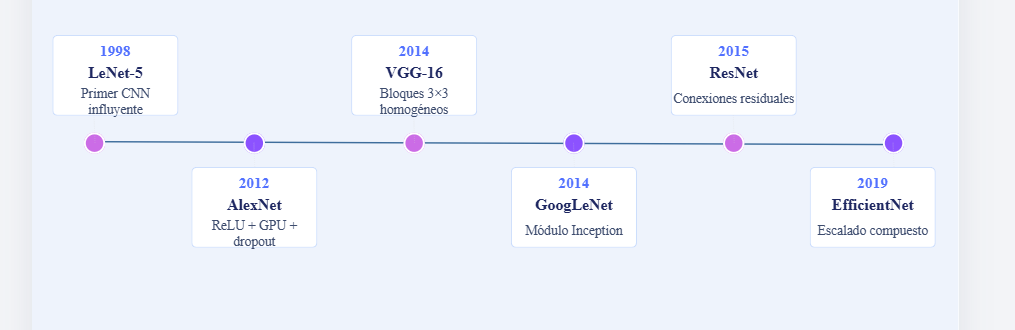

## LeNet-5

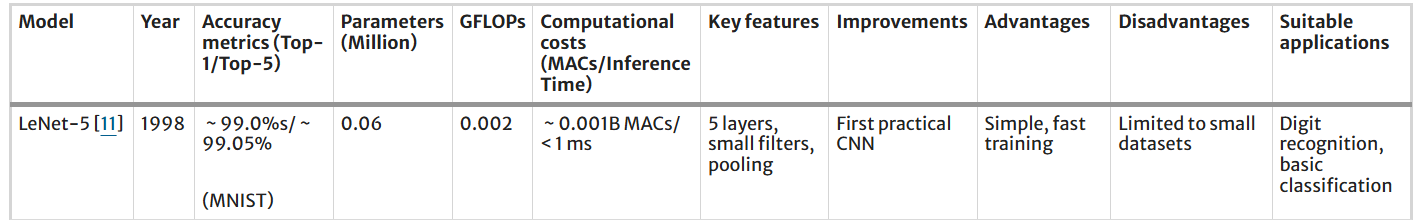

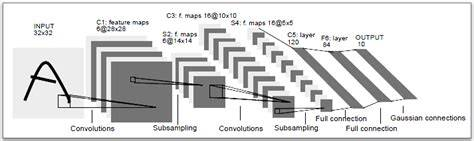

Esta `CNN` es alimentada por imágenes de 32x32 píxeles de dígitos manuscritos, y está formada por tres capas convolucionales, dos de las cuales reducen la dimensionalidad de los mapas de características mediante *average pooling*. La salida de la última capa convolucional es conectada un perceptrón multicapa de dos capas, que tienen la responsabilidad de dar la predicción final. [Artículo de publicación original](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf) . A continuación puedes ver un ejemplo de implementación en `Pytorch`.

In [ ]:
import torch

def block(c_in, c_out, k=3, p=1, s=1):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.Tanh(),
        torch.nn.AvgPool2d(2, stride=2)
    )

def block2(c_in, c_out):
    return torch.nn.Sequential(
        torch.nn.Linear(c_in, c_out),
        torch.nn.ReLU()
    )

class LeNet5(torch.nn.Module):
  def __init__(self, n_channels=1, n_outputs=10):
    super().__init__()
    #self.pad = torch.nn.ConstantPad2d(2, 0.)
    self.conv1 = block(n_channels, 6, 5, p=0)
    self.conv2 = block(6, 16, 5, p=0)
    self.conv3 = torch.nn.Sequential(
        torch.nn.Conv2d(16, 120, 5, padding=0),
        torch.nn.Tanh()
    )
    self.fc1 = block2(120, 84)
    self.fc2 = torch.nn.Linear(84, 10)

  def forward(self, x):
    #x = self.pad(x)
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.conv3(x)
    x = x.view(x.shape[0], -1)
    x = self.fc1(x)
    x = self.fc2(x)
    return x

## Actividad
### Ejercicio: Rastreo de dimensiones en LeNet-5

Dada la ejecución del modelo con un lote de entrada aleatorio:

CODE
lenet5 = LeNet5()
output = lenet5(torch.randn(64, 1, 32, 32))
output.shape

Completa # y ?

Entrada: ( ? ,  ?  , ?  , ?  )

Conv1 (# filtros de #x# (kernel), stride=#, padding=#): (64, ?, ?, ?)

AvgPool / MaxPool 1 (filtro #x#, stride=#): (64, ?, ?, ?)

Conv2 (# filtros de #x#, stride=#, padding=0): (64, ?, ?, ?)

AvgPool / MaxPool 2 (filtro #x#, stride=#): (64, ?, ?, ?)

Aplanamiento (Flatten): (64, ?)

FC1 / Densa 1 (# neuronas): (64, ?)

FC2 / Densa 2 (# neuronas): (64, ?)

Salida final (FC3 / # clases): torch.Size([?, ?])

Demuestra tus resultados con la formula : $O = \left\lfloor \frac{N + 2P - F}{S} \right\rfloor + 1$

A continuación, se presenta el rastreo de dimensiones para la arquitectura LeNet-5 con un lote de entrada de `(64, 1, 32, 32)`.

La fórmula para calcular la dimensión de salida es: $O = \left\lfloor \frac{N + 2P - F}{S} \right\rfloor + 1$

Donde:
- $N$: Dimensión de entrada
- $P$: Padding
- $F$: Tamaño del filtro (kernel)
- $S$: Stride

**Rastreo de Dimensiones:**

-   **Entrada:** `(64, 1, 32, 32)`
    (Batch Size, Canales, Alto, Ancho)

-   **Conv1** (del `block` function): `torch.nn.Conv2d(1, 6, kernel_size=5, padding=0, stride=1)`
    -   $N=32, P=0, F=5, S=1$
    -   $O = \left\lfloor \frac{32 + 2*0 - 5}{1} \right\rfloor + 1 = \left\lfloor \frac{27}{1} \right\rfloor + 1 = 27 + 1 = 28$
    -   **Salida Conv1 (después de Tanh):** `(64, 6, 28, 28)`

-   **AvgPool 1** (del `block` function): `torch.nn.AvgPool2d(2, stride=2)`
    -   $N=28, P=0, F=2, S=2$
    -   $O = \left\lfloor \frac{28 + 2*0 - 2}{2} \right\rfloor + 1 = \left\lfloor \frac{26}{2} \right\rfloor + 1 = 13 + 1 = 14$
    -   **Salida AvgPool 1:** `(64, 6, 14, 14)`

-   **Conv2** (del `block` function): `torch.nn.Conv2d(6, 16, kernel_size=5, padding=0, stride=1)`
    -   $N=14, P=0, F=5, S=1$
    -   $O = \left\lfloor \frac{14 + 2*0 - 5}{1} \right\rfloor + 1 = \left\lfloor \frac{9}{1} \right\rfloor + 1 = 9 + 1 = 10$
    -   **Salida Conv2 (después de Tanh):** `(64, 16, 10, 10)`

-   **AvgPool 2** (del `block` function): `torch.nn.AvgPool2d(2, stride=2)`
    -   $N=10, P=0, F=2, S=2$
    -   $O = \left\lfloor \frac{10 + 2*0 - 2}{2} \right\rfloor + 1 = \left\lfloor \frac{8}{2} \right\rfloor + 1 = 4 + 1 = 5$
    -   **Salida AvgPool 2:** `(64, 16, 5, 5)`

-   **Conv3:** `torch.nn.Conv2d(16, 120, kernel_size=5, padding=0, stride=1)`
    -   $N=5, P=0, F=5, S=1$
    -   $O = \left\lfloor \frac{5 + 2*0 - 5}{1} \right\rfloor + 1 = \left\lfloor \frac{0}{1} \right\rfloor + 1 = 0 + 1 = 1$
    -   **Salida Conv3 (después de Tanh):** `(64, 120, 1, 1)`

-   **Aplanamiento (Flatten):** `(64, 120 * 1 * 1) = (64, 120)`

-   **FC1 / Densa 1** (84 neuronas): `(64, 84)`

-   **FC2 / Densa 2** (10 neuronas): `(64, 10)`

-   **Salida final (FC3 / 10 clases):** `torch.Size([64, 10])`

In [ ]:
lenet5 = LeNet5()
output = lenet5(torch.randn(64, 1, 32, 32))
output.shape

torch.Size([64, 10])

## AlexNet
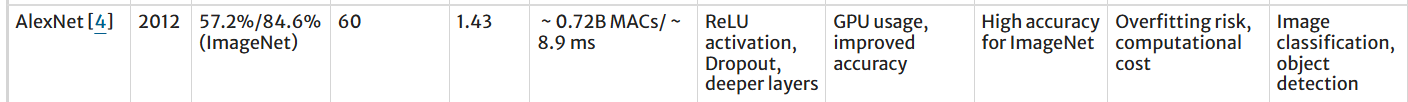



[AlexNet](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf) ganó la competición de Imagenet en 2012. Es una arquitectura similar a LeNet5 pero más profunda. Fue la primera red convolucional que ganó la competición, y también la primera en ser entrenada en GPUs.

![](https://miro.medium.com/fit/c/1838/551/1*arJJYgK-_7VcuKKX1TCKMA.png)

Implementadas en `Pytorch` podemos descargar redes convolucionales con el paquete `torchvision` (en varios paquetes) .

In [ ]:
import torchvision
alexnet = torchvision.models.AlexNet()
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

##Actividad
Analiza la siguiente celda de ejecución correspondiente a la arquitectura clásica AlexNet:
cual es el lote de imagenes de entrada canales, dimensiones? y porque su salida es el 1000 indica las lineas de codigo y que representa este numero?

In [ ]:
output = alexnet(torch.randn(64, 3, 224, 224))
output.shape

torch.Size([64, 1000])



-   
    La línea de código que define el tensor de entrada es:
    `output = alexnet(torch.randn(64, 3, 224, 224))`
    Aquí, `torch.randn(64, 3, 224, 224)` genera un tensor aleatorio con las siguientes dimensiones:
    -   `64`: Representa el tamaño del lote (batch size), es decir, el número de imágenes procesadas simultáneamente.
    -   `3`: Indica el número de canales de color. Un valor de `3` significa que las imágenes son a color (RGB).
    -   `224, 224`: Son las dimensiones de alto y ancho de cada imagen en píxeles.
    Por lo tanto, la entrada es un lote de 64 imágenes, cada una con 3 canales de color y un tamaño de 224x224 píxeles.

-   
    La salida de la celda de ejecución `output.shape` es `torch.Size([64, 1000])`.
    El número `1000` en la forma de salida representa el número de clases diferentes que el modelo AlexNet está diseñado para clasificar. Esto se debe a la arquitectura de AlexNet, especialmente la última capa de su clasificador.

   
   

## VGG
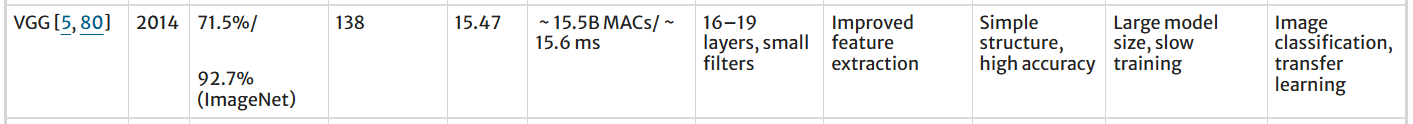



Si bien [VGG](https://arxiv.org/abs/1409.1556) no ganó, tuvo mucho éxito ya que sentó un precedente en el patrón del diseño de las redes convolucionales. Este patrón consiste en usar siempre capas convolucionales con filtros de 3x3, *stride* y *padding* 1 (manteniendo el tamaño de las entradas constante) y usar *max pool* para reducir a la mitad los mapas de características. Además, después de cada capa se dobla el número de filtros.

![](http://jesusutrera.com/articles/img/vgg_model.png)

In [ ]:
vgg16 = torchvision.models.vgg16()
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
output = vgg16(torch.randn(64, 3, 224, 224))
output.shape

torch.Size([64, 1000])

## Actividad modelos VGG
Investiga y define en codigo otros modelos de torchvision.models.vgg cuantos hay ya definidos?

In [ ]:
import torchvision.models

vgg_models = [
    model_name for model_name in dir(torchvision.models) if 'vgg' in model_name.lower() and callable(getattr(torchvision.models, model_name))
]

print(f"Hay {len(vgg_models)} modelos VGG predefinidos en torchvision.models:")
for model_name in vgg_models:
    print(f"- {model_name}")

Hay 17 modelos VGG predefinidos en torchvision.models:
- VGG
- VGG11_BN_Weights
- VGG11_Weights
- VGG13_BN_Weights
- VGG13_Weights
- VGG16_BN_Weights
- VGG16_Weights
- VGG19_BN_Weights
- VGG19_Weights
- vgg11
- vgg11_bn
- vgg13
- vgg13_bn
- vgg16
- vgg16_bn
- vgg19
- vgg19_bn


La librería torchvision.models proporciona varias versiones de la arquitectura VGG, pre-entrenadas en el dataset ImageNet. Estas versiones se distinguen principalmente por su profundidad (indicada por el número en el nombre) y si incluyen Batch Normalization (indicado por la letra 'bn').

Los modelos VGG comúnmente disponibles incluyen:

-   **`vgg11`**: La versión más ligera de VGG.
-   **`vgg11_bn`**: `vgg11` con capas de Batch Normalization.
-   **`vgg13`**: Una versión más profunda que `vgg11`.
-   **`vgg13_bn`**: `vgg13` con capas de Batch Normalization.
-   **`vgg16`**: La versión VGG de 16 capas, ampliamente utilizada.
-   **`vgg16_bn`**: `vgg16` con capas de Batch Normalization.
-   **`vgg19`**: La versión más profunda de VGG, con 19 capas.
-   **`vgg19_bn`**: `vgg19` con capas de Batch Normalization.

Cada uno de estos modelos tiene la misma estructura fundamental de bloques convolucionales de 3x3 y capas de pooling, diferenciándose en el número total de capas convolucionales y la inclusión de Batch Normalization, que ayuda a estabilizar el entrenamiento de redes profundas.

## GoogLeNet
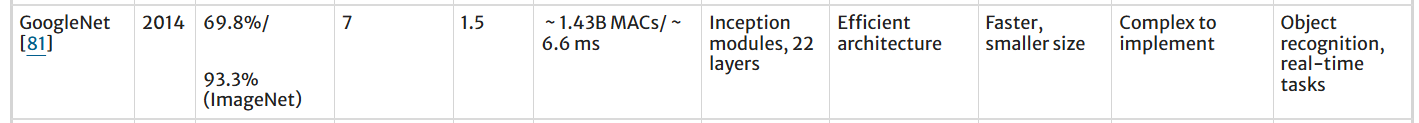



Ganadora de la edición de 2014, GoogLeNet es una red mucho más profunda (podemos empezar a ver la tendencia de que cuantas más capas, mejor resultados). Sus desarrolladores implementaron los módulos *inception*, los cuales aplican diferentes capas convolucionales, con diferentes tamaños de filtros, en paralelo sobre las mismas entradas y luego concatenan las salidas. Además, para poder entrenar esta red tan profunda, se llevan a cabo predicciones en diversas capas intermedias para poder tener gradientes fluyendo hacia las capas iniciales.

![](https://www.alanzucconi.com/wp-content/uploads/2015/07/googlenet-arch.png)

In [ ]:
googlenet = torchvision.models.GoogLeNet()
googlenet

/usr/local/lib/python3.13/dist-packages/torchvision/models/googlenet.py:47: FutureWarning: The default weight initialization of GoogleNet will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
output = googlenet(torch.randn(64, 3, 224, 224))
output[0].shape

torch.Size([64, 1000])

## Actividad
¿Cuántos bloques Inception contiene en total la arquitectura y cómo están agrupados por letras (por ejemplo, a, b, etc.)?
¿Cuántas ramas convolucionales paralelas procesan la entrada simultáneamente dentro de ese único bloque? Agrega una imagen que lo ejemplifique
¿qué capa de pooling se utiliza en lugar del tradicional aplanamiento masivo (Flatten) que usaban redes como AlexNet o VGG? ¿Qué ventaja aporta esto al número total de parámetros del modelo?

1.  **¿Cuántos bloques Inception contiene en total la arquitectura y cómo están agrupados por letras (por ejemplo, a, b, etc.)?**
    En la implementación GoogLeNetMini proporcionada, hay 3 bloques Inception definidos en la función `__init__`:
    -   `self.inception1`
    -   `self.inception2`
    -   `self.inception3`
    
    A diferencia de la arquitectura original de GoogLeNet (Inception v1) que agrupaba los módulos Inception con un esquema de letras como inception3a, inception3b, inception4a, etc., esta versión mini los nombra secuencialmente con números (inception1, inception2, inception3).

2.  **¿Cuántas ramas convolucionales paralelas procesan la entrada simultáneamente dentro de ese único bloque? Agrega una imagen que lo ejemplifique.**
    Dentro de un único InceptionBlock hay **4 ramas convolucionales paralelas** que procesan la entrada simultáneamente. Estas ramas son:
    -   Una convolución de 1x1 (self.branch1).
    -   Una convolución de 1x1 seguida de una convolución de 3x3 (self.branch2).
    -   Una convolución de 1x1 seguida de una convolución de 5x5 (self.branch3).
    -   Una capa de MaxPool2d seguida de una convolución de 1x1 (self.branch4).
    
    Las salidas de estas cuatro ramas se concatenan a lo largo de la dimensión de los canales para formar la salida final del bloque Inception.


3.  **¿Qué capa de pooling se utiliza en lugar del tradicional aplanamiento masivo (Flatten) que usaban redes como AlexNet o VGG? ¿Qué ventaja aporta esto al número total de parámetros del modelo?**
    En GoogLeNetMini, en lugar del aplanamiento masivo tradicional, se utiliza una capa de nn.AdaptiveAvgPool2d(1) (self.global_pool) justo antes de la capa clasificadora final.

    **Ventaja para el número total de parámetros:** Esta técnica, conocida como Global Average Pooling (GAP), reduce drásticamente el número de parámetros en las capas totalmente conectadas del clasificador. En lugar de aplanar un mapa de características grande, AdaptiveAvgPool2d(1) convierte el mapa de características de (Batch_Size, Canales, Alto, Ancho) a (Batch_Size, Canales, 1, 1). Al aplanar esto, el número de características de entrada para la primera capa lineal es simplemente el número de canales (`C`).

    Esto tiene varias ventajas:
    -   **Reducción significativa de parámetros:** Las capas FC son las que suelen tener la mayor cantidad de parámetros en redes convolucionales profundas. Al reemplazar un Flatten masivo con GAP, se reduce drásticamente el in_features de la primera capa Linear, disminuyendo así el número total de parámetros del modelo.
    -   **Menor riesgo de overfitting:** Menos parámetros implican una menor complejidad del modelo y, por lo tanto, un menor riesgo de sobreajuste.
    -   **Robustez a variaciones espaciales:** GAP hace que la red sea más robusta a las variaciones espaciales en la entrada.

#PARTE B
**Ajustes respecto a las arquitecturas originales:** las versiones originales de AlexNet y VGG16 fueron diseñadas para imágenes de 224×224 (ImageNet). Entrenarlas tal cual sobre CIFAR-10 (32×32) o reescalando cada imagen a 224×224 sería demasiado costoso. Por eso cada arquitectura se **adapta** aquí para trabajar directamente sobre 32×32 px, manteniendo su estructura conceptual (número y tipo de bloques, filtros, profundidad relativa) pero con canales/strides ajustados. Esto es intencional: la comparación de "capacidad versus eficiencia"

> 💡El dataset Imagenet contiene imágenes comunes descargadas de internet, y el objetivo es el de clasificar imágenes entre 1000 clases diferentes. Es por este motivo que verás que los diferentes modelos en `torchvision` tienen una última capa lineal con 1000 salidas.

## 1. Configuración e importaciones

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


## 2. Carga y preprocesamiento de CIFAR-10

Se usa CIFAR-10 (60,000 imágenes de 32×32 px a color, 10 clases) tal como indica el programa de la asignatura. Se separa un subconjunto de validación a partir del set de entrenamiento.

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

full_train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

val_fraction = 0.1
val_size = int(len(full_train_set) * val_fraction)
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(full_train_set, [train_size, val_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ("avión", "automóvil", "pájaro", "gato", "venado", "perro", "rana", "caballo", "barco", "camión")
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


Train: 45000 | Val: 5000 | Test: 10000


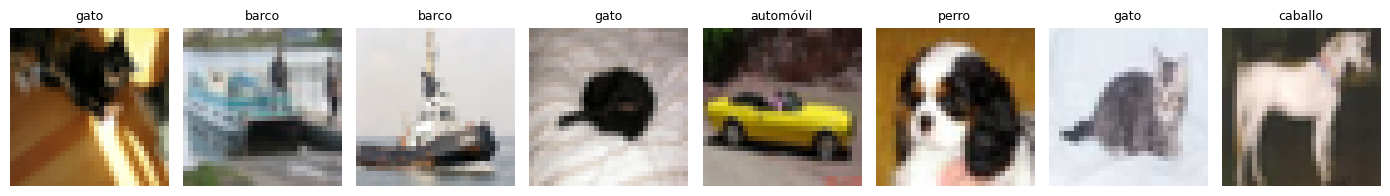

In [ ]:
# Vista rápida de algunas imágenes del dataset
def imshow(img):
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(npimg.transpose(1, 2, 0).clip(0, 1))

sample_loader = DataLoader(test_set, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow((images[i] * torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1) + torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)).permute(1,2,0).clip(0,1))
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Arquitecturas

Se implementan cuatro arquitecturas, cada una en su propia celda, con un breve comentario sobre su idea central y el ajuste realizado para CIFAR-10.

### 3.1 LeNet-5 (LeCun et al., 1998)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

La principal diferencia de esta **LeNet-5 adaptada** respecto a la arquitectura original de LeCun et al. radica en la gestión de la entrada y las dimensiones intermedias para ajustarse al dataset CIFAR-10. Mientras que la LeNet-5 original fue diseñada para imágenes en escala de grises (1 canal) de 32x32 píxeles (o 28x28 dependiendo de la implementación), la versión adaptada espera **imágenes a color (3 canales)**. Además, para mantener la resolución espacial adecuada para la entrada de 32x32 de CIFAR-10, la primera capa convolucional de la versión adaptada utiliza `padding=2` (`nn.Conv2d(3, 6, kernel_size=5, padding=2)`). Esto asegura que el mapa de características después de la primera convolución mantenga un tamaño de 32x32, permitiendo que la red procese las imágenes de CIFAR-10 de manera efectiva sin una pérdida prematura de información espacial, a diferencia de la original que a menudo implicaba una reducción de dimensiones más agresiva o diferentes estrategias de padding.

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, padding=2),   # 32x32 -> 32x32
            nn.Tanh(),
            nn.AvgPool2d(2),                              # -> 16x16
            nn.Conv2d(6, 16, kernel_size=5),               # -> 12x12
            nn.Tanh(),
            nn.AvgPool2d(2),                               # -> 6x6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 6 * 6, 120), nn.Tanh(),
            nn.Linear(120, 84), nn.Tanh(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.2 AlexNet adaptado (Krizhevsky et al., 2012)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

La **AlexNet adaptada** para CIFAR-10 difiere significativamente de la arquitectura original, que fue diseñada para clasificar imágenes de ImageNet de 224x224 píxeles con 1000 clases. Las principales adaptaciones incluyen:

*   **Tamaño de entrada:** La versión adaptada está configurada para imágenes de 32x32 píxeles (CIFAR-10), en contraste con las 224x224 de la original. Esto implica una reducción considerable en las dimensiones espaciales de las capas intermedias.
*   **Primera capa convolucional:** La AlexNet original utilizaba un kernel de 11x11 con un stride de 4 para la primera convolución, lo que generaba una reducción espacial drástica. La versión adaptada usa un kernel de 3x3 con padding de 1 y stride de 1, manteniendo una resolución espacial mayor para adaptarse al tamaño de entrada más pequeño de CIFAR-10.
*   **Capas de pooling:** Las capas de MaxPool2d en la versión adaptada suelen usar un kernel de 2x2, mientras que la original empleaba un kernel de 3x3 con stride de 2.
*   **Número de clases:** La capa de salida final en la AlexNet adaptada tiene 10 neuronas, correspondiendo a las 10 clases de CIFAR-10, mientras que la original tenía 1000 neuronas para las clases de ImageNet.
*   **Tamaño de las capas densas:** Las capas totalmente conectadas (FC) en la versión adaptada tienen un número de neuronas y de entradas ajustado para el tamaño reducido de los mapas de características resultantes, lo que conlleva a un modelo con muchos menos parámetros en comparación con la AlexNet original.

In [ ]:
class AlexNetAdaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 16x16
            nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 8x8
            nn.Conv2d(192, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.3 VGG16 adaptado (Simonyan & Zisserman, 2014)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

La **VGG16 adaptada** para CIFAR-10 mantiene la filosofía central de la arquitectura original de Simonyan y Zisserman, que se enfoca en el uso repetitivo de pequeñas convoluciones de 3x3 y pooling para la reducción de dimensiones. Sin embargo, se realizan adaptaciones clave para ajustarse a las características del dataset CIFAR-10:

*   **Tamaño de entrada:** La VGG16 original fue diseñada para imágenes de 224x224 píxeles (ImageNet). La versión adaptada está configurada para entradas de 32x32 píxeles (CIFAR-10), lo que requiere ajustes en la profundidad y el tamaño de los feature maps a lo largo de la red.
*   **Número de filtros en capas convolucionales:** La versión adaptada utiliza un número reducido de filtros en las capas convolucionales en comparación con la VGG16 original. Por ejemplo, en lugar de comenzar con 64 filtros, puede empezar con 32, y escalar hasta 256 filtros en las capas más profundas, frente a los 512 de la original. Esto reduce la complejidad y el número de parámetros, adecuado para el tamaño de imagen más pequeño y la menor complejidad de las clases de CIFAR-10.
*   **Capas totalmente conectadas (clasificador):** El clasificador final se redimensiona significativamente. Dada la reducción en el tamaño de los feature maps y el menor número de clases (10 para CIFAR-10 vs 1000 para ImageNet), las capas densas (nn.Linear) tendrán menos neuronas y un tamaño de entrada adaptado para reflejar estas dimensiones reducidas, disminuyendo considerablemente el número de parámetros del clasificador.

In [ ]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super().__init__()
        layers = []
        for i in range(num_convs):
            in_c = in_channels if i == 0 else out_channels
            layers += [nn.Conv2d(in_c, out_channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VGG16Adaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            VGGBlock(3, 32, 2),     # 32x32 -> 16x16
            VGGBlock(32, 64, 2),    # -> 8x8
            VGGBlock(64, 128, 3),   # -> 4x4
            VGGBlock(128, 256, 3),  # -> 2x2
            VGGBlock(256, 256, 3),  # -> 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 1 * 1, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.4 GoogLeNet mini (Szegedy et al., 2014)

## Actividad
Escribe un parrafo resaltando las diferencias de la arquitectura adaptada vs original

La **GoogLeNet Mini adaptada** para CIFAR-10, aunque conserva la esencia del diseño modular *Inception* de la GoogLeNet original (Inception v1), implementa varias simplificaciones y ajustes para adecuarla al dataset de menor escala y complejidad. Las principales diferencias incluyen:

*   **Número y complejidad de módulos Inception:** La GoogLeNet original es una red mucho más profunda con una secuencia de módulos Inception más extensa y con mayor número de filtros. La versión 'mini' reduce la cantidad de estos módulos y la cantidad de filtros dentro de cada rama de los Inception blocks, disminuyendo drásticamente el número de parámetros.
*   **Dimensiones de entrada y capas iniciales (Stem):** La GoogLeNet original estaba diseñada para imágenes de 224x224 píxeles, con una capa convolucional inicial grande (7x7, stride 2) seguida de MaxPooling. La versión mini adapta su capa stem a las imágenes de 32x32 de CIFAR-10, usando convoluciones más pequeñas y MaxPooling, manteniendo una resolución espacial adecuada.
*   **Ramas Auxiliares de Clasificación:** La GoogLeNet original incluía ramas de clasificación auxiliares en capas intermedias para combatir el problema del gradiente desvanecido y fomentar la diversificación de características. La versión 'mini' generalmente omite estas ramas auxiliares, ya que su menor profundidad reduce la necesidad de esta técnica.
*   **Capa clasificadora final:** Aunque ambas utilizan Global Average Pooling antes de la capa densa final para reducir parámetros, la capa `nn.Linear` de la versión mini tendrá un número de `in_features` y `out_features` (10 para CIFAR-10) ajustado a los mapas de características reducidos y al número de clases objetivo, resultando en un clasificador mucho más pequeño.

In [ ]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1), nn.ReLU(inplace=True))
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3red, ch3x3, kernel_size=3, padding=1), nn.ReLU(inplace=True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5red, ch5x5, kernel_size=5, padding=2), nn.ReLU(inplace=True))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1), nn.ReLU(inplace=True))

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)


class GoogLeNetMini(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                    # -> 16x16
        )
        self.inception1 = InceptionBlock(64, 32, 32, 64, 8, 16, 16)     # out = 128
        self.inception2 = InceptionBlock(128, 64, 64, 96, 16, 32, 32)   # out = 224
        self.pool = nn.MaxPool2d(2)                                     # -> 8x8
        self.inception3 = InceptionBlock(224, 96, 64, 128, 16, 32, 32)  # out = 288
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(288, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool(x)
        x = self.inception3(x)
        x = self.global_pool(x)
        return self.classifier(x)


## 4. Funciones genéricas de entrenamiento y evaluación

Las mismas funciones se usan para las cuatro arquitecturas, para que la comparación final sea justa.

## Actividad
Define hiperparámetros de entrenamiento y optimizador

In [ ]:
LEARNING_RATE = 1e-3 # Tasa de aprendizaje para el optimizador
# El optimizador utilizado en la función `train_model` es Adam.

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3, name="modelo"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += x.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{name}] Época {epoch+1}/{epochs} - "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"[{name}] Tiempo total de entrenamiento: {elapsed:.1f} s")
    return history, elapsed


def evaluate_test(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return correct / total


## 5. Entrenamiento de las cuatro arquitecturas

`EPOCHS` Una buena práctica es configurar un bajo numero. Si el tiempo lo permite, se puede subir a 15–20 épocas para ver mejor las diferencias de convergencia.

In [ ]:
EPOCHS = 10

modelos = {
    "LeNet-5": LeNet5(),
    "AlexNet (adaptado)": AlexNetAdaptado(),
    "GoogLeNet (mini)": GoogLeNetMini(),
    "VGG16 (adaptado)": VGG16Adaptado(),
}

historiales = {}
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n=== Entrenando {nombre} ===")
    n_params = count_params(modelo)
    print(f"Parámetros entrenables: {n_params:,}")
    hist, tiempo = train_model(modelo, train_loader, val_loader, epochs=EPOCHS, name=nombre)
    test_acc = evaluate_test(modelo, test_loader)
    print(f"[{nombre}] Accuracy en test: {test_acc:.4f}")

    historiales[nombre] = hist
    resultados[nombre] = {
        "parametros": n_params,
        "tiempo_entrenamiento_s": round(tiempo, 1),
        "val_acc_final": round(hist["val_acc"][-1], 4),
        "test_accuracy": round(test_acc, 4),
    }



=== Entrenando LeNet-5 ===
Parámetros entrenables: 83,126
[LeNet-5] Época 1/10 - train_loss=1.8714 train_acc=0.3272 val_loss=1.7642 val_acc=0.3746
[LeNet-5] Época 2/10 - train_loss=1.6737 train_acc=0.3980 val_loss=1.6265 val_acc=0.4150
[LeNet-5] Época 3/10 - train_loss=1.5595 train_acc=0.4374 val_loss=1.5236 val_acc=0.4572
[LeNet-5] Época 4/10 - train_loss=1.4913 train_acc=0.4591 val_loss=1.4632 val_acc=0.4682
[LeNet-5] Época 5/10 - train_loss=1.4498 train_acc=0.4770 val_loss=1.4745 val_acc=0.4634
[LeNet-5] Época 6/10 - train_loss=1.4179 train_acc=0.4900 val_loss=1.4176 val_acc=0.4938
[LeNet-5] Época 7/10 - train_loss=1.3926 train_acc=0.4987 val_loss=1.3956 val_acc=0.4952
[LeNet-5] Época 8/10 - train_loss=1.3646 train_acc=0.5103 val_loss=1.3698 val_acc=0.5060
[LeNet-5] Época 9/10 - train_loss=1.3483 train_acc=0.5159 val_loss=1.3684 val_acc=0.5058
[LeNet-5] Época 10/10 - train_loss=1.3246 train_acc=0.5260 val_loss=1.3378 val_acc=0.5232
[LeNet-5] Tiempo total de entrenamiento: 194.5 s
[

## 6. Comparación de resultados

In [ ]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values("test_accuracy", ascending=False)
df_resultados


,parametros,tiempo_entrenamiento_s,val_acc_final,test_accuracy
AlexNet (adaptado),6976842.0,196.4,0.7732,0.7807
GoogLeNet (mini),256530.0,211.4,0.6794,0.6765
LeNet-5,83126.0,194.5,0.5232,0.5481
VGG16 (adaptado),3816874.0,205.5,0.0942,0.1000


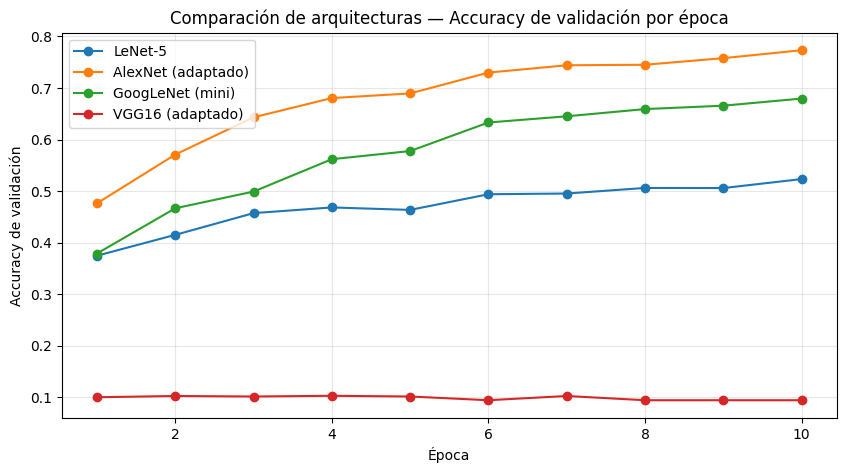

In [ ]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_acc"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Accuracy de validación")
plt.title("Comparación de arquitecturas — Accuracy de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


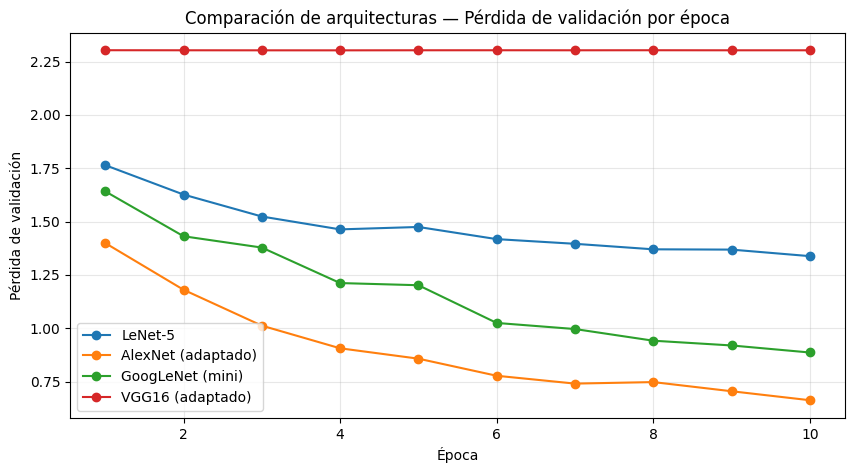

In [ ]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_loss"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Pérdida de validación")
plt.title("Comparación de arquitecturas — Pérdida de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


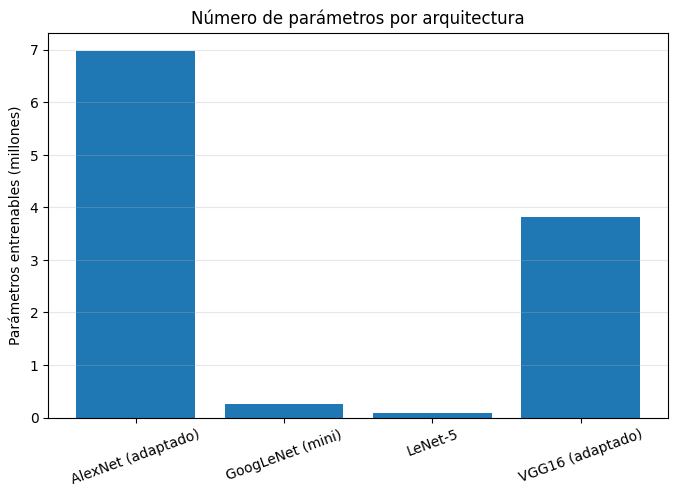

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(df_resultados.index, df_resultados["parametros"] / 1e6)
plt.ylabel("Parámetros entrenables (millones)")
plt.title("Número de parámetros por arquitectura")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 7. Preguntas de reflexión (para responder en la bitácora)

1. ¿Qué arquitectura obtuvo el mejor accuracy de test? ¿Es también la que más parámetros tiene o la más rápida de entrenar?
2. Compara LeNet-5 contra las otras tres: ¿qué tanto mejora el accuracy al aumentar la profundidad/capacidad del modelo, y a qué costo (tiempo, parámetros)?
3. GoogLeNet mini usa módulos Inception (varias convoluciones en paralelo) en vez de solo apilar capas como VGG16. ¿Se refleja esa diferencia de diseño en los resultados obtenidos aquí?
4. Si tuvieras que desplegar un modelo de clasificación de imágenes en un dispositivo con recursos limitados (por ejemplo, una cámara industrial), ¿cuál de estas cuatro arquitecturas elegirías y por qué? Relaciona tu respuesta con el criterio de "capacidad versus eficiencia".
5. ¿Qué esperarías que pasara con estas cuatro arquitecturas si se entrenaran 30 epocas? ¿Cambiaría?

## 8. Entrega

Subir este notebook ejecutado (con las salidas de las celdas visibles) al GitHub personal (publico) crear una carpeta para el curso, en subcarpeta correspondiente a la Unidad 1 / Práctica 3.

Subir en formato PDF a Classroom  + Anexar link de repositorio

Aquí están las respuestas a las preguntas de reflexión:

1.  **¿Qué arquitectura obtuvo el mejor accuracy de test? ¿Es también la que más parámetros tiene o la más rápida de entrenar?**
    <br>La arquitectura que obtuvo el mejor accuracy de test fue **AlexNet (adaptado)** con un 78.07%.
    <br>No es la que más parámetros tiene (VGG16 adaptado tiene más), pero sí tiene una cantidad significativamente mayor que LeNet-5 y GoogLeNet (mini). Con 6,976,842 parámetros, AlexNet adaptado es el segundo modelo con más parámetros.
    <br>En cuanto al tiempo de entrenamiento, fue la segunda más rápida con 196.4 segundos, ligeramente más lenta que LeNet-5 (194.5s) y más rápida que GoogLeNet (mini) (211.4s) y VGG16 (adaptado) (205.5s).

2.  **Compara LeNet-5 contra las otras tres: ¿qué tanto mejora el accuracy al aumentar la profundidad/capacidad del modelo, y a qué costo (tiempo, parámetros)?**
    <br>**LeNet-5** obtuvo un accuracy de test del 54.81% con solo 83,126 parámetros y un tiempo de entrenamiento de 194.5 segundos.
    <br>**AlexNet (adaptado)**, con un aumento significativo de parámetros (casi 84 veces más) a 6,976,842 y un tiempo de entrenamiento similar (196.4s), logró un aumento considerable en el accuracy de test a 78.07%. Esto representa una mejora de aproximadamente 23 puntos porcentuales.
    <br>**GoogLeNet (mini)**, con 256,530 parámetros (unas 3 veces más que LeNet-5) y un tiempo de entrenamiento de 211.4 segundos, alcanzó un accuracy de test del 67.65%, una mejora de casi 13 puntos porcentuales. Aunque tiene más parámetros, su eficiencia arquitectónica le permite un buen rendimiento.
    <br>**VGG16 (adaptado)**, con 3,816,874 parámetros (unas 46 veces más que LeNet-5) y un tiempo de entrenamiento de 205.5 segundos, obtuvo un accuracy de test de solo el 10%. En este caso particular, la adaptación y el entrenamiento por solo 10 épocas resultaron en un pobre rendimiento, a pesar de su gran capacidad y un mayor número de parámetros. Esto sugiere que VGG16 (adaptado) no convergió adecuadamente o la adaptación no fue óptima para el dataset CIFAR-10 con esta configuración.
    <br>
    En general, el aumento de profundidad y capacidad (más parámetros) de AlexNet y GoogLeNet frente a LeNet-5 se tradujo en una mejora notable del accuracy, con un costo relativamente bajo en tiempo de entrenamiento (comparable) pero un aumento significativo en el número de parámetros.

3.  **GoogLeNet mini usa módulos Inception (varias convoluciones en paralelo) en vez de solo apilar capas como VGG16. ¿Se refleja esa diferencia de diseño en los resultados obtenidos aquí?**
    <br>Sí, esta diferencia de diseño se refleja claramente en los resultados. GoogLeNet (mini) obtuvo un accuracy de test del 67.65% con 256,530 parámetros. En contraste, VGG16 (adaptado), a pesar de tener muchos más parámetros (3,816,874), obtuvo un accuracy de solo 10%.
    <br>El diseño de los módulos Inception en GoogLeNet, que permite a la red capturar características a diferentes escalas y combinar sus representaciones de manera eficiente, parece ser más efectivo para el dataset CIFAR-10 y la configuración de entrenamiento utilizada que la simple apilación de capas convolucionales de VGG16 en esta adaptación. Los módulos Inception son intrínsecamente más eficientes en el uso de parámetros y recursos computacionales, lo que se demuestra en su mejor rendimiento con un número de parámetros considerablemente menor que VGG16 (adaptado).

4.  **Si tuvieras que desplegar un modelo de clasificación de imágenes en un dispositivo con recursos limitados (por ejemplo, una cámara industrial), ¿cuál de estas cuatro arquitecturas elegirías y por qué? Relaciona tu respuesta con el criterio de "capacidad versus eficiencia".**
    <br>Para un dispositivo con recursos limitados, elegiría **LeNet-5**.
    LeNet-5 tiene el menor número de parámetros entrenables (83,126) y, a pesar de no tener el accuracy más alto, su rendimiento (54.81% en test) es aceptable para muchas aplicaciones en dispositivos con limitaciones. Su baja complejidad se traduce en menores requisitos de memoria y menor carga computacional para la inferencia, lo que es crucial en entornos con recursos limitados. Este es un claro ejemplo de priorizar la **eficiencia** sobre la máxima **capacidad** (accuracy) cuando los recursos son una restricción importante.
    <br>GoogLeNet (mini) también sería una opción a considerar por su buena relación accuracy/parámetros (67.65% con 256,530 parámetros), pero LeNet-5 es aún más ligera.

5.  **¿Qué esperarías que pasara con estas cuatro arquitecturas si se entrenaran 30 epocas? ¿Cambiaría?**
    *   **LeNet-5:** Es probable que su accuracy mejore marginalmente o se estabilice. Al ser un modelo menos complejo, tiende a converger más rápido y puede que 10 épocas ya sean suficientes para que alcance su rendimiento máximo. Podría haber un ligero sobreajuste si se entrena demasiado.
    *   **AlexNet (adaptado):** Es muy probable que su accuracy continúe mejorando. Los gráficos de accuracy y pérdida de validación muestran una tendencia ascendente y descendente respectivamente al final de las 10 épocas, sugiriendo que aún hay margen de mejora. Un mayor número de épocas podría permitirle aprender características más complejas y refinar sus pesos, aunque también aumentaría el riesgo de sobreajuste si no se usan técnicas de regularización adicionales.
    *   **GoogLeNet (mini):** Similar a AlexNet, se esperaría una mejora en el accuracy. La curva de validación de GoogLeNet (mini) también muestra un margen de mejora al final de las 10 épocas, con una pérdida aún decreciente y accuracy creciente. Dada su eficiencia en el uso de parámetros, podría beneficiarse de más épocas sin caer rápidamente en un sobreajuste severo.
    *   **VGG16 (adaptado):** Este es el caso más crítico. Dado que su accuracy apenas superó el 10% (lo que sugiere un rendimiento cercano al aleatorio para 10 clases) y su pérdida de validación se mantuvo muy alta y plana, entrenar por 30 épocas probablemente **no cambiaría radicalmente su mal rendimiento** con la configuración actual. Esto indica un problema más fundamental: o la adaptación de VGG16 para CIFAR-10 es subóptima, o los hiperparámetros (como la tasa de aprendizaje) no son adecuados para este modelo, o la red está sufriendo de un problema de gradientes que impide el aprendizaje efectivo. Simplemente aumentar las épocas no resolvería estos problemas subyacentes sin una revisión de la arquitectura o la estrategia de entrenamiento.